# **Future Of Deep Learning**

**Laboratorium:** Sieć Feed-Forward w PyTorch

**Zadanie**: Klasyfikacja chorób serca (Heart Disease Dataset)

**Dataset:** Zbiór heart.csv to klasyczny zestaw danych medycznych używany do predykcji chorób serca. Zawiera informacje o pacjentach (ciągłe i kategoryczne), takie jak wiek, płeć, ciśnienie krwi, poziom cholesterolu czy wyniki badań EKG, a zmienną docelową jest etykieta wskazująca, czy pacjent ma chorobę serca (1) czy nie (0).

**Źródło:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset


## Inżynieria wsteczna

### Przeanalizuj kod i wyniki ewaluacji modelu znajdujące się poniżej:

Mounted at /content/drive
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol     

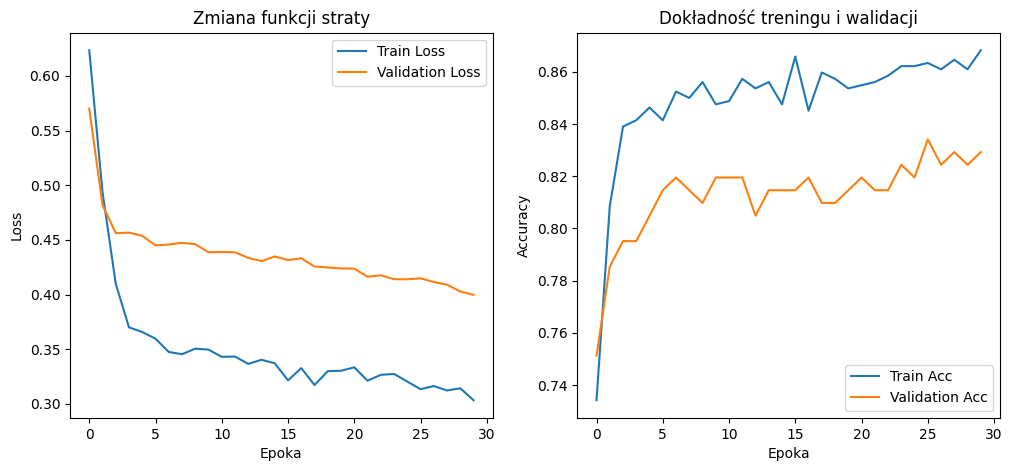

In [1]:
# --- Krok 0. Import bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from google.colab import drive
from sklearn.decomposition import PCA

# --- Wczytanie danych

drive.mount('/content/drive')
root = "/content/drive/MyDrive/"
data = pd.read_csv(root + "Colab Notebooks/datasets/heart.csv")
print(data.head())
print(data.info())

# --- Przygotowanie danych do trenowania modelu

# Podział danych na cechy (X) i etykiety (y)
# - X = wszystkie kolumny oprócz "target" (czyli informacje o pacjencie, np. wiek, ciśnienie, cholesterol itp.)
# - y = kolumna "target", czyli zmienna wyjściowa (czy pacjent ma chorobę serca: 0 = brak, 1 = obecna)
X = data.drop("target", axis=1).values
y = data["target"].values

# Normalizacja cech numerycznych
# - StandardScaler skaluje każdą cechę tak, żeby miała średnią = 0 i odchylenie standardowe = 1
# - Dzięki temu model szybciej i stabilniej się uczy, bo wszystkie cechy są w podobnym zakresie wartości
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA – redukcja do 5 wymiarów / cech
pca = PCA(n_components=5) # inicjalizacja PCA – redukcja danych do 5 głównych składowych
X_pca = pca.fit_transform(X_scaled) # dopasowanie PCA do danych i przekształcenie cech na 5 wymiarów

# Podział danych na zbiór treningowy i testowy
# - 80% danych do treningu (X_train, y_train)
# - 20% danych do testu (X_test, y_test)
# - random_state = 42 -> zapewnia powtarzalność wyników
# - stratify=y -> zachowuje proporcję klas (0 i 1) w obu podzbiorach
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Konwersja danych do tensora PyTorch
# - Tensory to podstawowy typ danych w PyTorch (odpowiednik tablic NumPy, ale działają na GPU)
# - FloatTensor: dane wejściowe X (ciągłe wartości)
# - LongTensor: etykiety y (klasy całkowitoliczbowe: 0 lub 1)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Utworzenie Datasetów i DataLoaderów
# - TensorDataset łączy X i y w jeden obiekt (czyli wejście i etykieta są sparowane)
# - DataLoader umożliwia efektywne pobieranie danych partiami (batch_size=32)
# - shuffle=True dla treningu: kolejność danych jest losowana, żeby model nie uczył się kolejności przykładów
# - dla testu shuffle=False (domyślnie), bo kolejność nie ma znaczenia przy ewaluacji
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# --- Model

class NeuralNet(nn.Module):

    # Definicja struktury sieci (inicjalizacja warstw)
    def __init__(self):
        super(NeuralNet, self).__init__()  # inicjalizacja klasy bazowej nn.Module
        self.fc1 = nn.Linear(5, 64)  # warstwa w pełni połączona: 5 wejść -> 64 neurony
        self.dropout1 = nn.Dropout(0.2)  # dropout 20% po pierwszej warstwie
        self.fc2 = nn.Linear(64, 32)  # druga warstwa: 64 -> 32 neurony
        self.dropout2 = nn.Dropout(0.2)  # dropout 20% po drugiej warstwie
        self.fc3 = nn.Linear(32, 1)  # warstwa wyjściowa: 32 -> 1 neuron
        self.sigmoid = nn.Sigmoid()  # funkcja aktywacji sigmoid na wyjściu

    # Definicja propagacji do przodu (forward pass)
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU po pierwszej warstwie
        x = self.dropout1(x)  # dropout w trakcie treningu
        x = torch.relu(self.fc2(x))  # ReLU po drugiej warstwie
        x = self.dropout2(x)  # dropout w trakcie treningu
        x = self.sigmoid(self.fc3(x))  # sigmoid na wyjściu -> prawdopodobieństwo klasy 1
        return x  # zwraca predykcję

model = NeuralNet()

# --- Loss i optimizer

# BCELoss = Binary Cross-Entropy Loss
# - Funkcja straty dla problemów klasyfikacji binarnej (0 lub 1)
# - Porównuje predykcje modelu (sigmoid outputs) z prawdziwymi etykietami
# - Minimalizacja tej straty oznacza, że model lepiej dopasowuje swoje wyjścia do oczekiwanych wartości
criterion = nn.BCELoss()

# Adam = adaptacyjny optymalizator, który automatycznie dopasowuje współczynniki uczenia dla każdej wagi
# lr=0.001 = współczynnik uczenia, określa jak duże kroki robi model w kierunku minimalizacji straty
# weight_decay=1e-4 = regularyzacja L2, zmniejsza ryzyko przeuczenia (overfittingu) poprzez karanie dużych wag
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# --- Funkcja treningowa

def train_model(model, train_loader, test_loader, epochs=20):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()  # Ustawiamy model w tryb treningu (aktywne dropouty i batchnorm, jeśli są)
        total_loss = 0  # Sumaryczna strata w trakcie epoki
        correct_train, total_train = 0, 0  # Licznik poprawnych predykcji i wszystkich próbek

        # --- Pętla treningowa ---
        for xb, yb in train_loader:
            optimizer.zero_grad()  # Zerowanie gradientów z poprzedniego kroku
            outputs = model(xb)  # Forward pass: obliczenie wyjścia modelu
            loss = criterion(outputs, yb)  # Obliczenie straty (BCELoss)
            loss.backward()  # Backpropagation: obliczenie gradientów
            optimizer.step()  # Aktualizacja wag modelu
            total_loss += loss.item()  # Sumowanie straty dla tej epoki

            # --- Liczenie poprawnych predykcji ---
            preds = (outputs >= 0.5).int().view(-1)  # Binarna decyzja dla sigmoid (0 lub 1)
            correct_train += (preds == yb.int().view(-1)).sum().item()  # Zliczenie poprawnych predykcji
            total_train += yb.size(0)  # Dodanie liczby próbek w batchu

        acc_train = correct_train / total_train  # Obliczenie dokładności treningowej

        # --- Ewaluacja na zbiorze walidacyjnym ---
        model.eval()  # Ustawienie modelu w tryb ewaluacji (dropouty i batchnorm wyłączone)
        val_loss = 0
        y_pred, y_true = [], []  # Listy do przechowywania predykcji i prawdziwych etykiet

        with torch.no_grad():  # Wyłączanie śledzenia gradientów dla wydajności
            for xb, yb in test_loader:
                outputs = model(xb)  # Forward pass na zbiorze walidacyjnym
                loss = criterion(outputs, yb)  # Obliczenie straty walidacyjnej
                val_loss += loss.item()  # Sumowanie straty

                preds = (outputs >= 0.5).int().view(-1)  # Binarne predykcje
                y_pred.extend(preds.numpy())  # Zbieranie predykcji
                y_true.extend(yb.int().view(-1).numpy())  # Zbieranie prawdziwych etykiet

        acc_val = accuracy_score(y_true, y_pred)  # Obliczenie dokładności walidacyjnej

        # Historia
        history["train_loss"].append(total_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(test_loader))
        history["train_acc"].append(acc_train)
        history["val_acc"].append(acc_val)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {total_loss/len(train_loader):.4f}, "
              f"Val Loss: {val_loss/len(test_loader):.4f}, "
              f"Train Acc: {acc_train:.4f}, Val Acc: {acc_val:.4f}")

    return history


# --- Trening modelu
# Uczymy model przez 30 epok, a wyniki zapisujemy w DataFrame, aby móc je łatwo analizować i rysować wykresy.
history = train_model(model, train_loader, test_loader, epochs=30)
history_df = pd.DataFrame(history)

# --- Krok 6. Wizualizacja wyników
# Rysujemy wykresy strat i dokładności w czasie (dla treningu i walidacji).
# Dzięki temu widzimy:
# - czy model faktycznie uczy się (spadająca strata),
# - czy nie występuje overfitting (walidacja ≈ trening),
# - jak poprawia się dokładność klasyfikacji w kolejnych epokach.
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df['train_loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.title('Zmiana funkcji straty')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_df['train_acc'], label='Train Acc')
plt.plot(history_df['val_acc'], label='Validation Acc')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.title('Dokładność treningu i walidacji')
plt.legend()

plt.show()

## Wnioski

Przebieg uczenia pokazuje, że model szybko poprawił swoje wyniki w pierwszych epokach – strata treningowa spadła z **0.625** do ok. **0.32–0.34**, a dokładność treningu wzrosła z **75% do 86%**. Strata walidacyjna oscyluje wokół **0.41–0.44**, a dokładność walidacji stabilizuje się na poziomie **79–83%**.

**Strata walidacyjna** wyraźnie **wyższa od treningowej**, prawdopodbnie oznacza, że model nie wykorzystał w pełni informacji z danych i istnieje margines do poprawy generalizacji. Z drugiej strony wyrażnie **mniejsza dokładność walidacyjna** (3–7 punktów procentowych)  sugeruje, że model częściowo nadmiernie dopasowuje się do danych treningowych, mimo że overfitting nie jest dramatyczny.

## Zadanie


Wszystko wskazuje na to, że możliwe jest poprawienie aktulanych wyników.
**Spóbuj odpowiednio zmodyfikować architekturę**.


Epoch 1/30 | Train Loss: 0.6787, Val Loss: 0.6060, Train Acc: 0.5817, Val Acc: 0.7073
Epoch 2/30 | Train Loss: 0.5589, Val Loss: 0.5244, Train Acc: 0.7183, Val Acc: 0.7659
Epoch 3/30 | Train Loss: 0.4910, Val Loss: 0.4791, Train Acc: 0.8110, Val Acc: 0.7805
Epoch 4/30 | Train Loss: 0.4422, Val Loss: 0.4509, Train Acc: 0.8220, Val Acc: 0.7951
Epoch 5/30 | Train Loss: 0.4223, Val Loss: 0.4316, Train Acc: 0.8256, Val Acc: 0.7951
Epoch 6/30 | Train Loss: 0.3880, Val Loss: 0.4231, Train Acc: 0.8390, Val Acc: 0.8146
Epoch 7/30 | Train Loss: 0.3785, Val Loss: 0.4034, Train Acc: 0.8378, Val Acc: 0.8195
Epoch 8/30 | Train Loss: 0.3614, Val Loss: 0.4096, Train Acc: 0.8646, Val Acc: 0.8146
Epoch 9/30 | Train Loss: 0.3482, Val Loss: 0.3978, Train Acc: 0.8634, Val Acc: 0.8341
Epoch 10/30 | Train Loss: 0.3556, Val Loss: 0.3934, Train Acc: 0.8463, Val Acc: 0.8439
Epoch 11/30 | Train Loss: 0.3361, Val Loss: 0.3856, Train Acc: 0.8695, Val Acc: 0.8293
Epoch 12/30 | Train Loss: 0.3337, Val Loss: 0.3742, 

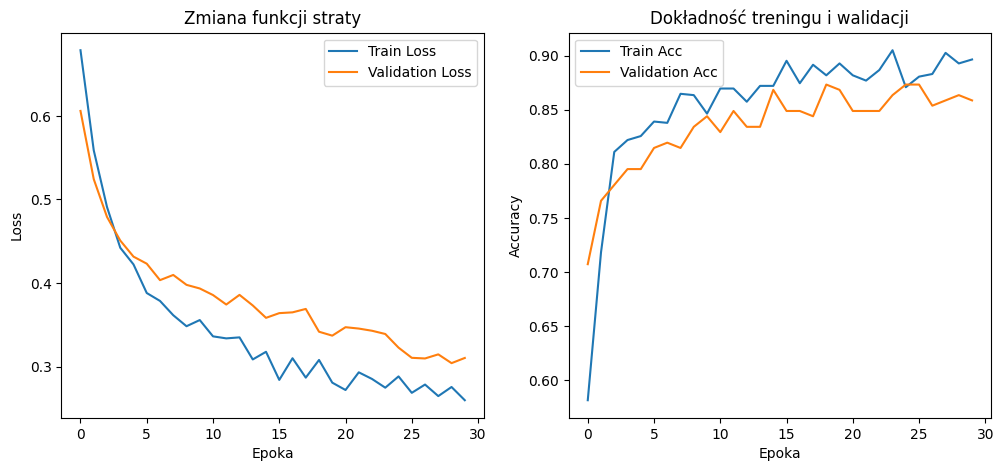

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42 #zamiast X_pca - X_scaled
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


class NeuralNetV2(nn.Module):
    def __init__(self):
        super(NeuralNetV2, self).__init__()
        self.fc1 = nn.Linear(13, 64)
        self.bn1 = nn.BatchNorm1d(64)   # warstawa normalizacji
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)  # dropout ->

        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32).   # warstawa normalizacji
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4)  # dropout ->

        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

model = NeuralNetV2()

# Funkcja straty
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4) # weight_decay ->

# Trening
history = train_model(model, train_loader, test_loader, epochs=30)
history_df = pd.DataFrame(history)

# Wizualizacja
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df['train_loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.title('Zmiana funkcji straty')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_df['train_acc'], label='Train Acc')
plt.plot(history_df['val_acc'], label='Validation Acc')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.title('Dokładność treningu i walidacji')
plt.legend()

plt.show()

Próba polepszyć model:
- Usunęłem PCA, ponieważ za bardzo kompresuje zbiór danych na których uczy się model [Początkowo próbowałem zwiększać liczbę parametrów ale nie zmieniło to wyników]
- Zwiększyłem Dropuot, żeby model mniej przeuczał się
- Zwiększyłem wieght_decay [L2 regulerizacja] do 5e-4
- Dodałem warstwę normalizacji, co jeszcze bardziej polepszyło model

Wnioski:

Udało się polepszyć model. Próbowałem też zmieniać learning_rate i ilość epoch, ale też nie polepszyło to wynik
